In [1]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta 


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

In [1]:
import os

image_directory = 'cell_images/'

print("cell_images:", os.path.exists(image_directory))
print("Parasitized:", os.path.exists(image_directory + 'Parasitized/'))
print("Uninfected:", os.path.exists(image_directory + 'Uninfected/'))

cell_images: True
Parasitized: True
Uninfected: True


In [2]:
SIZE = 150
dataset = []
label = []

parasitized_images = os.listdir(image_directory + 'Parasitized/')

for image_name in parasitized_images:
    if image_name.lower().endswith('.png'):
        image = cv2.imread(image_directory + 'Parasitized/' + image_name)
        image = Image.fromarray(image, 'RGB')
        image = image.resize((SIZE, SIZE))
        dataset.append(np.array(image))
        label.append(0)

print("Parasitized images loaded:", len(dataset))

NameError: name 'cv2' is not defined

In [6]:
import cv2
import numpy as np
from PIL import Image

In [7]:
SIZE = 150
dataset = []
label = []

parasitized_images = os.listdir(image_directory + 'Parasitized/')

for image_name in parasitized_images:
    if image_name.lower().endswith('.png'):
        image = cv2.imread(image_directory + 'Parasitized/' + image_name)
        image = Image.fromarray(image, 'RGB')
        image = image.resize((SIZE, SIZE))
        dataset.append(np.array(image))
        label.append(0)

print("Parasitized images loaded:", len(dataset))

Parasitized images loaded: 13779


In [8]:
uninfected_images = os.listdir(image_directory + 'Uninfected/')

for image_name in uninfected_images:
    if image_name.lower().endswith('.png'):
        image = cv2.imread(image_directory + 'Uninfected/' + image_name)
        image = Image.fromarray(image, 'RGB')
        image = image.resize((SIZE, SIZE))
        dataset.append(np.array(image))
        label.append(1)

print("Total images loaded:", len(dataset))


Total images loaded: 27558


In [9]:
dataset = np.array(dataset)
label = np.array(label)

print("Dataset shape:", dataset.shape)
print("Label shape:", label.shape)

Dataset shape: (27558, 150, 150, 3)
Label shape: (27558,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    dataset,
    label,
    test_size=0.20,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (22046, 150, 150, 3)
X_test: (5512, 150, 150, 3)
y_train: (22046,)
y_test: (5512,)


In [11]:
from keras.utils import normalize

X_train = normalize(X_train, axis=1)
X_test = normalize(X_test, axis=1)

print("Normalization completed!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

ModuleNotFoundError: No module named 'keras'

In [12]:
%pip install tensorflow

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.8 MB 259.2 kB/s eta 0:22:34
   ---------------------------------------- 0.1/350.8 MB 297.7 kB/s eta 0:19:39
   ---------------------------------------- 0.1/350.8 MB 297.7 kB/s eta 0:19:39
   ---------------------------------------- 0.1/350.8 MB 261.4 kB/s eta 0:22:22
   ---------------------------------------- 0.1/350.8 MB 290.5 kB/s eta 0:20:08
   ---------------------------------------- 0.1/350.8 MB 311.2 kB/s eta 0:18:47
   ---------------------------------------- 0.1/350.8 MB 311.2 kB/s eta 0:18:47
   ---------------------------------------- 0.1/350.8 MB 276.8 kB/s eta 0:21:08
   ---------------------------------------- 0.1/350.8 MB 283.8 kB/s eta 0:20:36
   ---------------------------------------- 0.2/350.8 MB 277.8 kB/s


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import tensorflow as tf
from keras.utils import normalize

print("TensorFlow:", tf.__version__)
print("Keras ready!")

TensorFlow: 2.21.0
Keras ready!


In [14]:
X_train = normalize(X_train, axis=1)
X_test = normalize(X_test, axis=1)

print("Normalization completed!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Normalization completed!
X_train shape: (22046, 150, 150, 3)
X_test shape: (5512, 150, 150, 3)


In [15]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense

INPUT_SHAPE = (SIZE, SIZE, 3)

model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=INPUT_SHAPE))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3), kernel_initializer='he_uniform'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), kernel_initializer='he_uniform'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\MathanKumar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 148, 148, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 72, 72, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 34, 34, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18496)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,183,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,212,513 (4.63 MB)

 Trainable params: 1,212,513 (4.63 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 102s 289ms/step - accuracy: 0.6582 - loss: 0.5854 - val_accuracy: 0.9421 - val_loss: 0.1986
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 89s 257ms/step - accuracy: 0.9446 - loss: 0.2110 - val_accuracy: 0.9427 - val_loss: 0.1859
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 88s 256ms/step - accuracy: 0.9509 - loss: 0.1804 - val_accuracy: 0.9528 - val_loss: 0.1639
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 88s 256ms/step - accuracy: 0.9541 - loss: 0.1645 - val_accuracy: 0.9523 - val_loss: 0.1576
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 92s 267ms/step - accuracy: 0.9569 - loss: 0.1477 - val_accuracy: 0.9492 - val_loss: 0.1621
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 92s 267ms/step - accuracy: 0.9588 - loss: 0.1349 - val_accuracy: 0.9575 - val_loss: 0.1455
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 90s 259ms/step - accuracy: 0.9624 - loss: 0.1275 - val_accuracy: 0.9565 - val_loss: 0.1529
Epoch 8/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 94s 272ms/step - accuracy: 0.9635 - loss: 

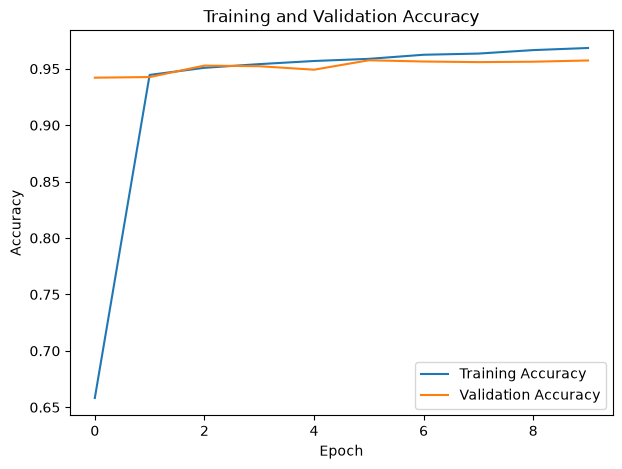

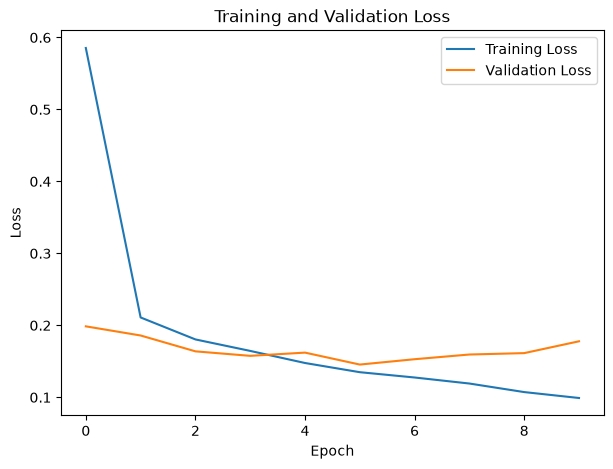

In [17]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Accuracy
plt.figure(figsize=(7, 5))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(7, 5))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [18]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9574 - loss: 0.1779
Test Loss: 0.1778523325920105
Test Accuracy: 0.9573657512664795
Test Accuracy (%): 95.73657512664795


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_prob = model.predict(X_test, verbose=1).ravel()

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Parasitized", "Uninfected"]
    )
)

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step
Confusion Matrix:
[[2549  154]
 [  81 2728]]

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.97      0.94      0.96      2703
  Uninfected       0.95      0.97      0.96      2809

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



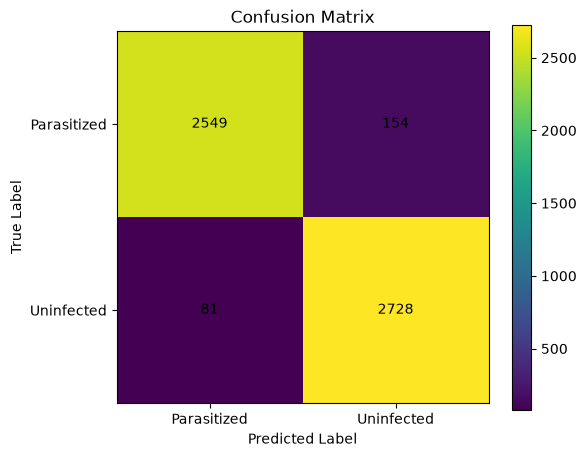

In [20]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Parasitized", "Uninfected"])
plt.yticks([0, 1], ["Parasitized", "Uninfected"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

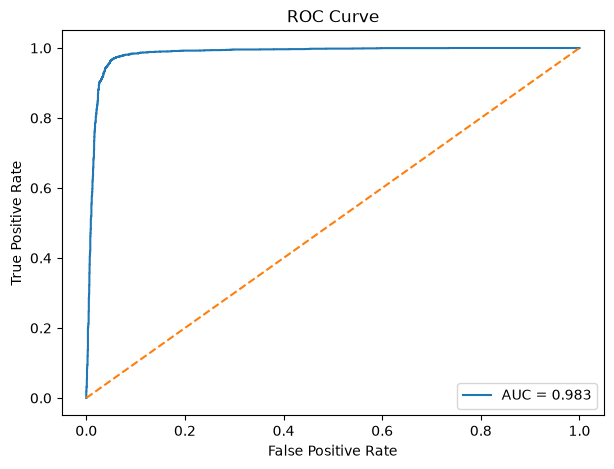

AUC: 0.9832975029920079


In [21]:
from sklearn.metrics import roc_curve, auc

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [22]:
model.save("malaria_model_10epochs.h5")
print("Model saved successfully!")

Model saved successfully!


In [23]:
print("===== Predictive Modeling Results =====")
print("Total images:", len(dataset))
print("Training images:", len(X_train))
print("Testing images:", len(X_test))
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)
print("AUC:", roc_auc)

===== Predictive Modeling Results =====
Total images: 27558
Training images: 22046
Testing images: 5512
Test Accuracy: 0.9573657512664795
Test Accuracy (%): 95.73657512664795
AUC: 0.9832975029920079
